In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =====================================
# 📘 KNN Classification with KMeans-SMOTE
# =====================================

import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import KMeansSMOTE

In [3]:
# =======================
# === Block 1: Load Data
# =======================
train_path = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/train_split.csv"
test_path  = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/test_split.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

print("✅ Data Loaded Successfully!")
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

✅ Data Loaded Successfully!
Train shape: (329623, 13)
Test shape: (82406, 13)


In [4]:
# ==============================
# === Block 2: Split Features
# ==============================
target_col = "PM2.5_level"
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]
X_test  = df_test.drop(columns=[target_col])
y_test  = df_test[target_col]

In [5]:
# =====================================
# === Block 3: Apply KMeans-SMOTE
# =====================================
from collections import Counter
from imblearn.over_sampling import KMeansSMOTE

# ตรวจสอบ class distribution ก่อน oversampling
class_counts = Counter(y_train)
print("\nBefore KMeans-SMOTE:", class_counts)

# หา class ที่มีจำนวนมากที่สุด (majority)
majority_class_count = max(class_counts.values())

# คำนวณเป้าหมาย: 50% ของจำนวนคลาสที่มากที่สุด
target_size = int(majority_class_count * 0.5)

# สร้าง sampling strategy สำหรับเฉพาะ class ที่ต้องการเพิ่ม (เช่น 2 และ 3)
sampling_strategy = {
    cls: target_size for cls in [2, 3] if class_counts[cls] < target_size
}

print("Dynamic sampling strategy:", sampling_strategy)

# ใช้ KMeans-SMOTE ตาม strategy ที่คำนวณได้
kmeans_smote = KMeansSMOTE(
    sampling_strategy=sampling_strategy,
    random_state=42,
    cluster_balance_threshold=0.01
)
X_resampled, y_resampled = kmeans_smote.fit_resample(X_train, y_train)

# ตรวจสอบผลลัพธ์หลัง oversampling
print("\nAfter KMeans-SMOTE:", Counter(y_resampled))


Before KMeans-SMOTE: Counter({5: 128801, 4: 73062, 1: 64314, 2: 33504, 3: 29942})
Dynamic sampling strategy: {2: 64400, 3: 64400}

After KMeans-SMOTE: Counter({5: 128801, 4: 73062, 2: 64404, 3: 64403, 1: 64314})


In [6]:
# ==========================================
# === Block 4: 10-Fold Cross Validation (with Mean ± SD)
# ==========================================
from sklearn.metrics import classification_report
import os

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = []
accuracy_list, precision_list, recall_list, f1_list, auc_scores = [], [], [], [], []

print("=== 10-Fold Cross Validation Results ===")

# ✅ แปลงเป็น numpy array
X_resampled = np.array(X_resampled)
y_resampled = np.array(y_resampled)
classes = np.unique(y_resampled)

start_time = time.time()

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_resampled, y_resampled), 1):
    X_tr, X_val = X_resampled[train_idx], X_resampled[val_idx]
    y_tr, y_val = y_resampled[train_idx], y_resampled[val_idx]

    model = KNeighborsClassifier(n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)

    y_val_bin = label_binarize(y_val, classes=sorted(classes))
    y_pred_bin = label_binarize(y_pred, classes=sorted(classes))
    fold_auc = roc_auc_score(y_val_bin, y_pred_bin, average="weighted", multi_class="ovr")

    results.append([fold, acc, prec, rec, f1, fold_auc])
    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)
    auc_scores.append(fold_auc)

# === สรุปตาราง ===
cv_df = pd.DataFrame(results, columns=["Fold", "Accuracy", "Precision", "Recall", "F1", "AUC_ROC"])
print(cv_df)

# === คำนวณ Mean ± SD ===
acc_mean, acc_sd = np.mean(accuracy_list), np.std(accuracy_list)
prec_mean, prec_sd = np.mean(precision_list), np.std(precision_list)
rec_mean, rec_sd = np.mean(recall_list), np.std(recall_list)
f1_mean, f1_sd = np.mean(f1_list), np.std(f1_list)
auc_mean, auc_sd = np.mean(auc_scores), np.std(auc_scores)

# === แสดงผลรวม (Mean ± SD) ===
print("\n📊 Cross-validation (10 folds) Metrics (Mean ± SD):")
print(f"Accuracy : {acc_mean:.3f} ± {acc_sd:.3f}")
print(f"Precision: {prec_mean:.3f} ± {prec_sd:.3f}")
print(f"Recall   : {rec_mean:.3f} ± {rec_sd:.3f}")
print(f"F1-score : {f1_mean:.3f} ± {f1_sd:.3f}")
print(f"AUC-ROC  : {auc_mean:.3f} ± {auc_sd:.3f}")

end_time = time.time()
print(f"\n⏱ Completed in {end_time - start_time:.2f} seconds")



=== 10-Fold Cross Validation Results ===
   Fold  Accuracy  Precision    Recall        F1   AUC_ROC
0     1  0.766146   0.767409  0.766146  0.765202  0.854696
1     2  0.765209   0.766221  0.765209  0.764412  0.854131
2     3  0.765867   0.766968  0.765867  0.765143  0.854580
3     4  0.766273   0.767571  0.766273  0.765294  0.854865
4     5  0.767659   0.768502  0.767659  0.766653  0.855554
5     6  0.763532   0.764876  0.763532  0.762738  0.853115
6     7  0.765355   0.767314  0.765355  0.764809  0.854325
7     8  0.766368   0.768207  0.766368  0.765645  0.855087
8     9  0.762672   0.764021  0.762672  0.761963  0.852697
9    10  0.764444   0.765932  0.764444  0.763705  0.853741

📊 Cross-validation (10 folds) Metrics (Mean ± SD):
Accuracy : 0.765 ± 0.001
Precision: 0.767 ± 0.001
Recall   : 0.765 ± 0.001
F1-score : 0.765 ± 0.001
AUC-ROC  : 0.854 ± 0.001

⏱ Completed in 185.05 seconds


In [7]:
# 💾 (Optional) บันทึกค่า Mean ± SD ลงไฟล์ CSV
cv_summary = pd.DataFrame([{
    "Accuracy_mean": acc_mean, "Accuracy_sd": acc_sd,
    "Precision_mean": prec_mean, "Precision_sd": prec_sd,
    "Recall_mean": rec_mean, "Recall_sd": rec_sd,
    "F1_mean": f1_mean, "F1_sd": f1_sd,
    "AUC_mean": auc_mean, "AUC_sd": auc_sd
}])

# ✅ Path ที่ใช้บันทึก
base_path = '/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/2-3/MeanSD/'
summary_path = base_path + "2-3KNN_Kmeans_MeanSD.csv"

# ✅ สร้างโฟลเดอร์อัตโนมัติ (กัน error ถ้าไม่มี)
os.makedirs(base_path, exist_ok=True)

# ✅ บันทึกไฟล์
cv_summary.to_csv(summary_path, index=False)
print(f"💾 Mean + SD summary saved to {summary_path}")

💾 Mean + SD summary saved to /content/drive/MyDrive/Senior_Project/roc/KNN_Roc/2-3/MeanSD/2-3KNN_Kmeans_MeanSD.csv


In [8]:
# =====================================
# === Block 5: Final Testing & Report
# =====================================
from sklearn.metrics import classification_report

model.fit(X_resampled, y_resampled)
y_pred_test = model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred_test)
test_prec = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_rec = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, average='weighted')

y_test_bin = label_binarize(y_test, classes=sorted(classes))
y_pred_test_bin = label_binarize(y_pred_test, classes=sorted(classes))
test_auc = roc_auc_score(y_test_bin, y_pred_test_bin, average="weighted", multi_class="ovr")

# === แสดงผลรวม ===
print(f"\n📈 Test Set Metrics:")
print(f"Accuracy: {test_acc:.3f}, Precision: {test_prec:.3f}, Recall: {test_rec:.3f}, F1: {test_f1:.3f}, AUC: {test_auc:.3f}")

# === Classification Report ===
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, digits=2))

# === Confusion Matrix ===
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(



📈 Test Set Metrics:
Accuracy: 0.714, Precision: 0.725, Recall: 0.714, F1: 0.718, AUC: 0.823

Classification Report:
              precision    recall  f1-score   support

           1       0.78      0.80      0.79     16078
           2       0.38      0.41      0.40      8376
           3       0.35      0.44      0.39      7486
           4       0.68      0.58      0.63     18265
           5       0.90      0.89      0.89     32201

    accuracy                           0.71     82406
   macro avg       0.62      0.62      0.62     82406
weighted avg       0.73      0.71      0.72     82406

Confusion Matrix:
[[12826  2210   821   165    56]
 [ 2541  3446  1882   473    34]
 [  620  1941  3303  1475   147]
 [  322  1216  3066 10666  2995]
 [   40   143   431  2957 28630]]


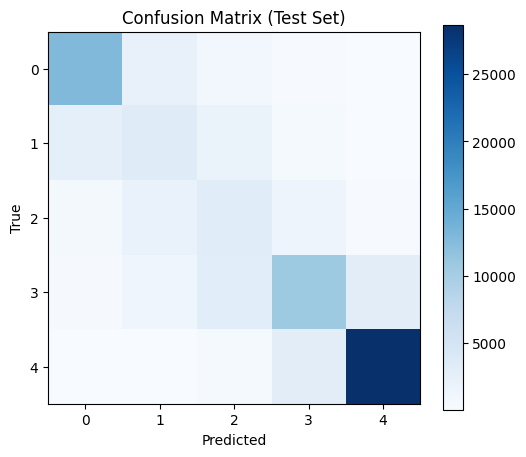

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


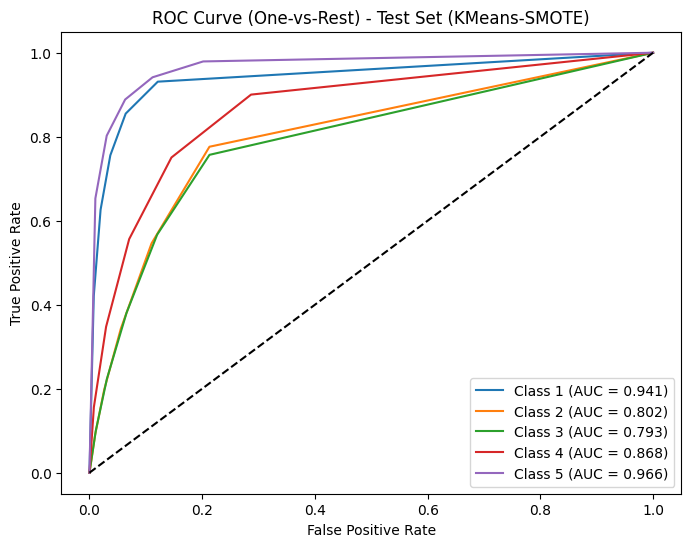

In [9]:
# ==========================================
# === Block6: Confusion Matrix & ROC Curve ===
# ==========================================
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.show()

# --- 2) ROC Curve (One-vs-Rest) ---
classes = model.classes_     # ✅ ใช้ชื่อโมเดลจริงที่เทรนไว้
n_classes = len(classes)

# แปลง y_test เป็น one-hot
y_test_bin = label_binarize(y_test, classes=classes)

# ใช้ probability จากโมเดล
y_pred_proba_test = model.predict_proba(X_test)

# คำนวณ fpr, tpr, auc
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- 3) พล็อต ROC ---
plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) - Test Set (KMeans-SMOTE)')
plt.legend()
plt.show()

In [ ]:
# =====================================
# === Block 7: Save Model & AUC Result
# =====================================
base_path = '//content/drive/MyDrive/Senior_Project/roc/KNN_Roc/Class2-3/'

joblib.dump(model, base_path + '2-3knn_kmeans.pkl')
print(f"💾 Model saved as {base_path}2-3knn_kmeans.pkl")

auc_df = pd.DataFrame({
    "Fold": list(range(1, 11)) + ["Test Set"],
    "AUC_ROC": auc_scores + [test_auc]
})
auc_df.to_csv(base_path + '2-3knn_kmeans_auc.csv', index=False)
print(f"💾 AUC-ROC values saved to {base_path}2-3knn_kmeans_auc.csv")

# === คำนวณ ROC ด้วย predict_proba (เหมือน Borderline) ===
classes = model.classes_
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_proba_test = model.predict_proba(X_test)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

roc_points = []
for i in range(n_classes):
    for fp, tp in zip(fpr[i], tpr[i]):
        roc_points.append({'Class': i, 'FPR': fp, 'TPR': tp})
# === Save FPR and TPR for each class ===
roc_df = pd.DataFrame(roc_points)
roc_df.to_csv(base_path + '2-3knn_kmeans_roc_points.csv', index=False)
print(f"💾 ROC points saved as {base_path}2-3knn_kmeans_roc_points.csv")

💾 Model saved as //content/drive/MyDrive/Senior_Project/roc/KNN_Roc/Class2-3/2-3knn_kmeans.pkl
💾 AUC-ROC values saved to //content/drive/MyDrive/Senior_Project/roc/KNN_Roc/Class2-3/2-3knn_kmeans_auc.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


💾 ROC points saved as //content/drive/MyDrive/Senior_Project/roc/KNN_Roc/Class2-3/2-3knn_kmeans_roc_points.csv
